# Reducción de Dimensiones — WISDM Smartphone and Smartwatch Activity and Biometrics Dataset

**Dataset:** [WISDM Smartphone and Smartwatch Activity and Biometrics Dataset](https://archive-beta.ics.uci.edu/dataset/507/wisdm+smartphone+and+smartwatch+activity+and+biometrics+dataset)

El dataset contiene información obtenida de los acelerómetros y giroscopios de *smartphones* y *smartwatches* de 50 voluntarios (identificados de 1600 a 1650, sin el 1614) mientras realizaban 18 actividades diferentes.

**Objetivo de este notebook:**

1. Seleccionar aleatoriamente 3 sujetos (muestras) del dataset.
2. Para cada sujeto y para cada combinación dispositivo-sensor (`phone-accel`, `phone-gyro`, `watch-accel`, `watch-gyro`):
   - Construir la matriz de características usando las columnas `xyzbins` (`X0`...`X9`, `Y0`...`Y9`, `Z0`...`Z9`) y el *ground truth* `ACTIVITY`.
   - Visualizar los datos en 2D usando **PCA**, **MDS Clásico**, **MDS Métrico**, **MDS No-métrico** y **UMAP**.
3. Repetir el ejercicio uniendo la información de los 3 sujetos en una sola matriz, para cada una de las 4 combinaciones dispositivo-sensor.
4. Discutir qué actividades se diferencian mejor y cuáles se superponen en las proyecciones 2D.

En todas las figuras los puntos se colorean según la columna `ACTIVITY`.


## 1. Instalación e importación de librerías

In [22]:
try:
    import numpy as np
except ImportError:
    %pip install numpy
    import numpy as np
try:
    import scipy as sp
except ImportError:
    %pip install scipy
    import scipy as sp
try:
    import pandas as pd
except ImportError:
    %pip install pandas
    import pandas as pd
try:
    import matplotlib.pyplot as plt
except ImportError:
    %pip install matplotlib
    import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    %pip install seaborn
    import seaborn as sns
try:
    import sklearn as skl
except ImportError:
    %pip install scikit-learn
    import sklearn as skl
try:
    import umap
except ImportError:
    %pip install umap-learn
    import umap

import random
import glob
import os


## 2. Selección aleatoria de 3 sujetos

Los sujetos están codificados de 1600 a 1650 (no existe el 1614). Se seleccionan 3 aleatoriamente.

> Se fija una semilla (`random.seed`) únicamente para que la selección sea reproducible al re-ejecutar el notebook. Cámbiela o elimínela si desea otra selección aleatoria.


In [23]:
random.seed(40)  # cambie o elimine esta línea para obtener otra selección aleatoria

POSSIBLE_IDS = [i for i in range(1600, 1651) if i != 1614]
SUBJECTS = sorted(random.sample(POSSIBLE_IDS, 3))
print("Sujetos seleccionados aleatoriamente:", SUBJECTS)


Sujetos seleccionados aleatoriamente: [1630, 1634, 1638]


## 3. Descarga del dataset WISDM

Se descarga el archivo comprimido oficial del repositorio UCI, que contiene (entre otros) el directorio `arff_files/`
con los datos ya transformados en histogramas (`xyzbins`) por sujeto, dispositivo (`phone`/`watch`) y sensor (`accel`/`gyro`).

Esta celda solo necesita ejecutarse una vez.


In [24]:
# Esta celda debe ejecutarse solamente una vez.
# Se usa urllib + zipfile (Python puro) en lugar de !wget/!unzip, para que funcione
# igual en Google Colab, Jupyter local o VS Code (Windows, Mac o Linux), sin depender
# de que existan los comandos de shell 'wget' y 'unzip'.
import urllib.request
import zipfile

WISDM_ZIP_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00507/wisdm-dataset.zip"
ZIP_PATH = "wisdm-dataset.zip"
DATA_DIR = "wisdm_data"

def _dataset_already_extracted():
    return os.path.isdir(DATA_DIR) and len(glob.glob(f"{DATA_DIR}/**/*.arff", recursive=True)) > 0

if not _dataset_already_extracted():
    print("Descargando el dataset WISDM (puede tardar 1-2 minutos, son ~700 MB)...")
    req = urllib.request.Request(WISDM_ZIP_URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as response, open(ZIP_PATH, "wb") as out_file:
        out_file.write(response.read())

    size_mb = os.path.getsize(ZIP_PATH) / (1024 ** 2)
    print(f"Descarga completa: {ZIP_PATH} ({size_mb:.1f} MB)")

    print("Descomprimiendo...")
    os.makedirs(DATA_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    print("Descompresión completa.")
else:
    print("El dataset ya está descargado en", DATA_DIR)

# Verificación: localizar archivos .arff dentro del directorio descomprimido.
# Si esto imprime 0 archivos, algo falló en la descarga/descompresión: revise
# manualmente si '{ZIP_PATH}' se descargó bien y si '{DATA_DIR}' tiene contenido.
sample_files = glob.glob(f"{DATA_DIR}/**/*.arff", recursive=True)
print(f"Se encontraron {len(sample_files)} archivos .arff")
print(sample_files[:4])

if len(sample_files) == 0:
    raise RuntimeError(
        "No se encontró ningún archivo .arff tras la descarga/descompresión. "
        "Verifique su conexión a internet y que la carpeta 'wisdm_data' y el archivo "
        "'wisdm-dataset.zip' se hayan creado correctamente en el directorio de trabajo."
    )


El dataset ya está descargado en wisdm_data
Se encontraron 200 archivos .arff
['wisdm_data\\wisdm-dataset\\arff_files\\phone\\accel\\data_1600_accel_phone.arff', 'wisdm_data\\wisdm-dataset\\arff_files\\phone\\accel\\data_1601_accel_phone.arff', 'wisdm_data\\wisdm-dataset\\arff_files\\phone\\accel\\data_1602_accel_phone.arff', 'wisdm_data\\wisdm-dataset\\arff_files\\phone\\accel\\data_1603_accel_phone.arff']


## 4. Funciones de carga y preparación de datos

In [25]:
xyzbins = ["X0","X1","X2","X3","X4","X5","X6","X7","X8","X9",
           "Y0","Y1","Y2","Y3","Y4","Y5","Y6","Y7","Y8","Y9",
           "Z0","Z1","Z2","Z3","Z4","Z5","Z6","Z7","Z8","Z9"]

# Mapeo de código de actividad (columna ACTIVITY) a nombre legible,
# según la documentación oficial del dataset (activity_key.txt)
ACTIVITY_NAMES = {
    "A": "Walking",
    "B": "Jogging",
    "C": "Stairs",
    "D": "Sitting",
    "E": "Standing",
    "F": "Typing",
    "G": "Brushing Teeth",
    "H": "Eating Soup",
    "I": "Eating Chips",
    "J": "Eating Pasta",
    "K": "Drinking from Cup",
    "L": "Eating Sandwich",
    "M": "Kicking Soccer Ball",
    "O": "Playing Catch (Tennis Ball)",
    "P": "Dribbling Basketball",
    "Q": "Writing",
    "R": "Clapping",
    "S": "Folding Clothes",
}

# Las 4 combinaciones dispositivo-sensor solicitadas
CASES = {
    "phone-accel": ("phone", "accel"),
    "phone-gyro":  ("phone", "gyro"),
    "watch-accel": ("watch", "accel"),
    "watch-gyro":  ("watch", "gyro"),
}


def find_arff_path(subject_id, device, sensor):
    """Localiza el archivo .arff correspondiente sin asumir la estructura exacta
    de carpetas dentro del zip descomprimido."""
    pattern = f"{DATA_DIR}/**/data_{subject_id}_{sensor}_{device}.arff"
    matches = glob.glob(pattern, recursive=True)
    if not matches:
        raise FileNotFoundError(
            f"No se encontró el archivo para subject={subject_id}, device={device}, sensor={sensor}"
        )
    return matches[0]


def load_arff_df(subject_id, device, sensor):
    """Carga un archivo .arff del dataset y limpia las columnas de texto."""
    path = find_arff_path(subject_id, device, sensor)
    raw, meta = sp.io.arff.loadarff(path)
    df = pd.DataFrame(raw)
    df.columns = df.columns.str.replace('"', "", regex=False)
    df["ACTIVITY"] = df["ACTIVITY"].str.decode("utf-8")
    if "class" in df.columns:
        df["class"] = df["class"].str.decode("utf-8")
    df["ACTIVITY_NAME"] = df["ACTIVITY"].map(ACTIVITY_NAMES).fillna(df["ACTIVITY"])
    return df


def build_case_matrix(subject_id, device, sensor):
    """Construye la matriz de características (xyzbins) y el ground truth (ACTIVITY)
    para un sujeto y una combinación dispositivo-sensor dada."""
    df = load_arff_df(subject_id, device, sensor)
    X = df[xyzbins].values.astype(float)
    y_code = df["ACTIVITY"].values
    y_name = df["ACTIVITY_NAME"].values
    return X, y_code, y_name


## 5. Funciones de reducción de dimensionalidad y visualización

Se implementan las 5 técnicas solicitadas:

- **PCA**: proyección lineal sobre las componentes de mayor varianza.
- **MDS Clásico (Torgerson / *classical scaling*)**: se implementa manualmente mediante la
  descomposición espectral de la matriz de distancias doblemente centrada. *(Nota: con distancias
  euclidianas, el MDS clásico es matemáticamente equivalente a PCA, salvo rotación/signo; por eso
  ambas figuras suelen lucir muy similares.)*
- **MDS Métrico**: `sklearn.manifold.MDS(metric=True)`, que usa el algoritmo iterativo SMACOF para
  minimizar el *stress* preservando las distancias originales.
- **MDS No-métrico**: `sklearn.manifold.MDS(metric=False)`, que preserva únicamente el orden relativo
  de las distancias (usa regresión isotónica).
- **UMAP**: proyección no lineal basada en preservar la estructura topológica local de los datos.

Todas las técnicas se aplican sobre los datos estandarizados (`StandardScaler`).


In [26]:
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances


def run_pca(X):
    return PCA(n_components=2, random_state=42).fit_transform(X)


def run_classical_mds(X):
    """MDS clásico (Torgerson): descomposición espectral de la matriz de
    distancias euclidianas doblemente centrada."""
    D = pairwise_distances(X, metric="euclidean")
    n = D.shape[0]
    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J
    eigvals, eigvecs = np.linalg.eigh(B)
    order = np.argsort(eigvals)[::-1]
    eigvals = np.clip(eigvals[order][:2], 0, None)
    eigvecs = eigvecs[:, order][:, :2]
    return eigvecs * np.sqrt(eigvals)


def run_metric_mds(X, n_init=4, max_iter=300):
    mds = MDS(n_components=2, metric=True, dissimilarity="euclidean",
              random_state=42, n_init=n_init, max_iter=max_iter,
              normalized_stress="auto", n_jobs=-1)
    return mds.fit_transform(X)


def run_nonmetric_mds(X, n_init=4, max_iter=300):
    mds = MDS(n_components=2, metric=False, dissimilarity="euclidean",
              random_state=42, n_init=n_init, max_iter=max_iter,
              normalized_stress="auto", n_jobs=-1)
    return mds.fit_transform(X)


def run_umap(X):
    reducer = umap.UMAP(n_components=2, random_state=42)
    return reducer.fit_transform(X)


TECHNIQUES = {
    "PCA": run_pca,
    "MDS Clásico": run_classical_mds,
    "MDS Métrico": run_metric_mds,
    "MDS No-métrico": run_nonmetric_mds,
    "UMAP": run_umap,
}


def reduce_all(X, scale=True, n_init=4, max_iter=300):
    """Aplica las 5 técnicas de reducción de dimensiones sobre X y devuelve
    un diccionario {nombre_tecnica: embedding_2D}."""
    Xs = StandardScaler().fit_transform(X) if scale else X
    results = {}
    for name, fn in TECHNIQUES.items():
        if name in ("MDS Métrico", "MDS No-métrico"):
            results[name] = fn(Xs, n_init=n_init, max_iter=max_iter)
        else:
            results[name] = fn(Xs)
    return results


In [27]:
def plot_embeddings(results, y_name, title):
    """Grafica en una fila los embeddings 2D de cada técnica, coloreando por ACTIVITY."""
    activities = sorted(pd.unique(y_name))
    cmap = plt.get_cmap("tab20", max(len(activities), 1))
    color_map = {a: cmap(i) for i, a in enumerate(activities)}
    colors = [color_map[a] for a in y_name]

    n_tec = len(results)
    fig, axes = plt.subplots(1, n_tec, figsize=(5 * n_tec, 5))
    if n_tec == 1:
        axes = [axes]
    for ax, (name, emb) in zip(axes, results.items()):
        ax.scatter(emb[:, 0], emb[:, 1], c=colors, s=12, alpha=0.75)
        ax.set_title(name)
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")

    handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=color_map[a], label=a)
               for a in activities]
    fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5), title="ACTIVITY")
    fig.suptitle(title, y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()


## 6. Parte 1 — Análisis individual por muestra

Para cada uno de los 3 sujetos seleccionados y cada una de las 4 combinaciones dispositivo-sensor
(`phone-accel`, `phone-gyro`, `watch-accel`, `watch-gyro`) se construye la matriz `xyzbins`, el
*ground truth* `ACTIVITY`, y se visualiza en 2D con las 5 técnicas.


Sujeto 1630 - phone-accel: 321 filas, 30 columnas, 18 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


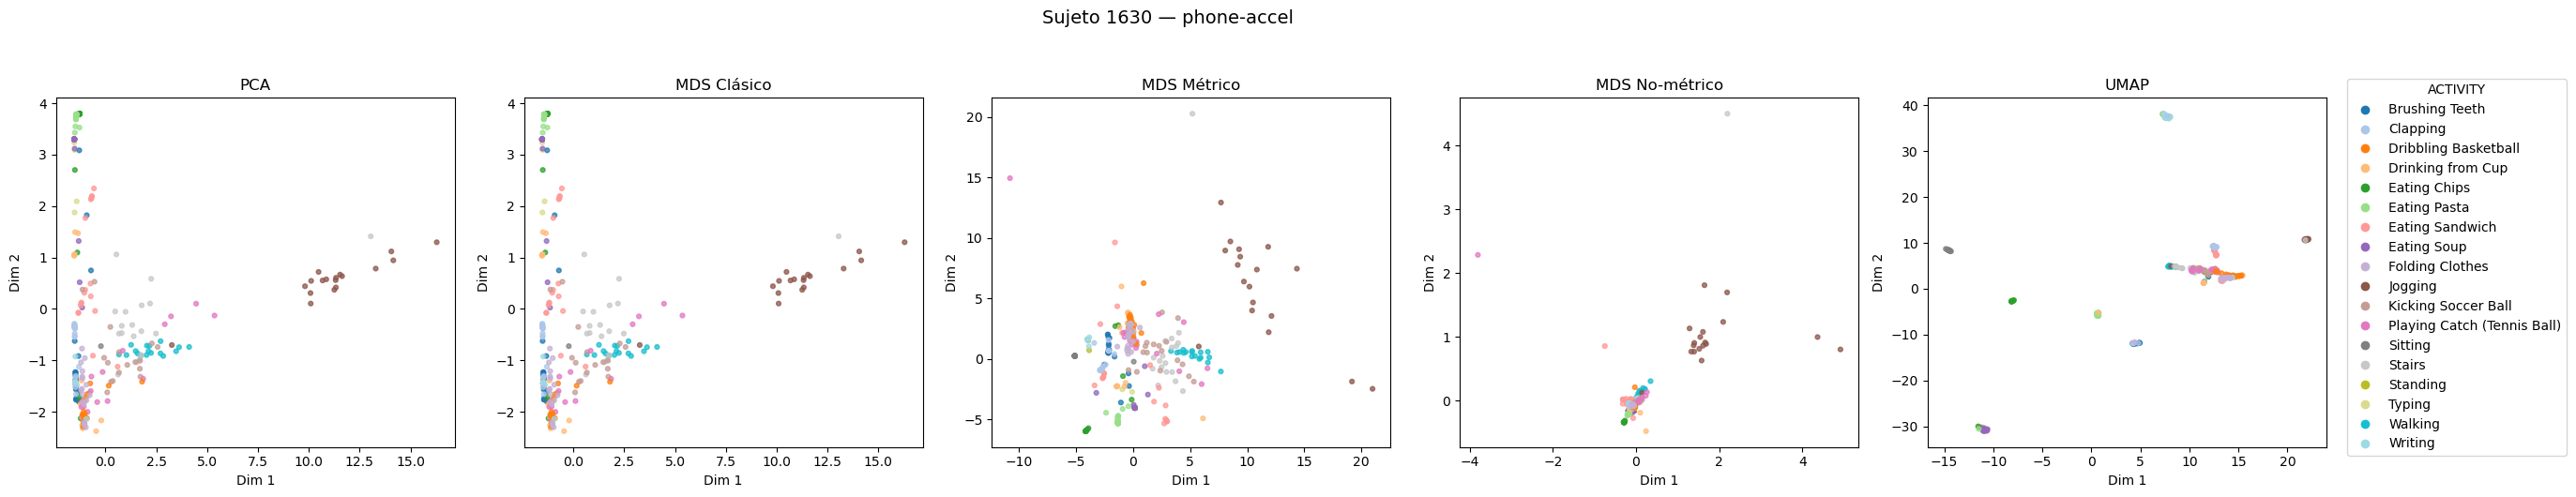

Sujeto 1630 - phone-gyro: 321 filas, 30 columnas, 18 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


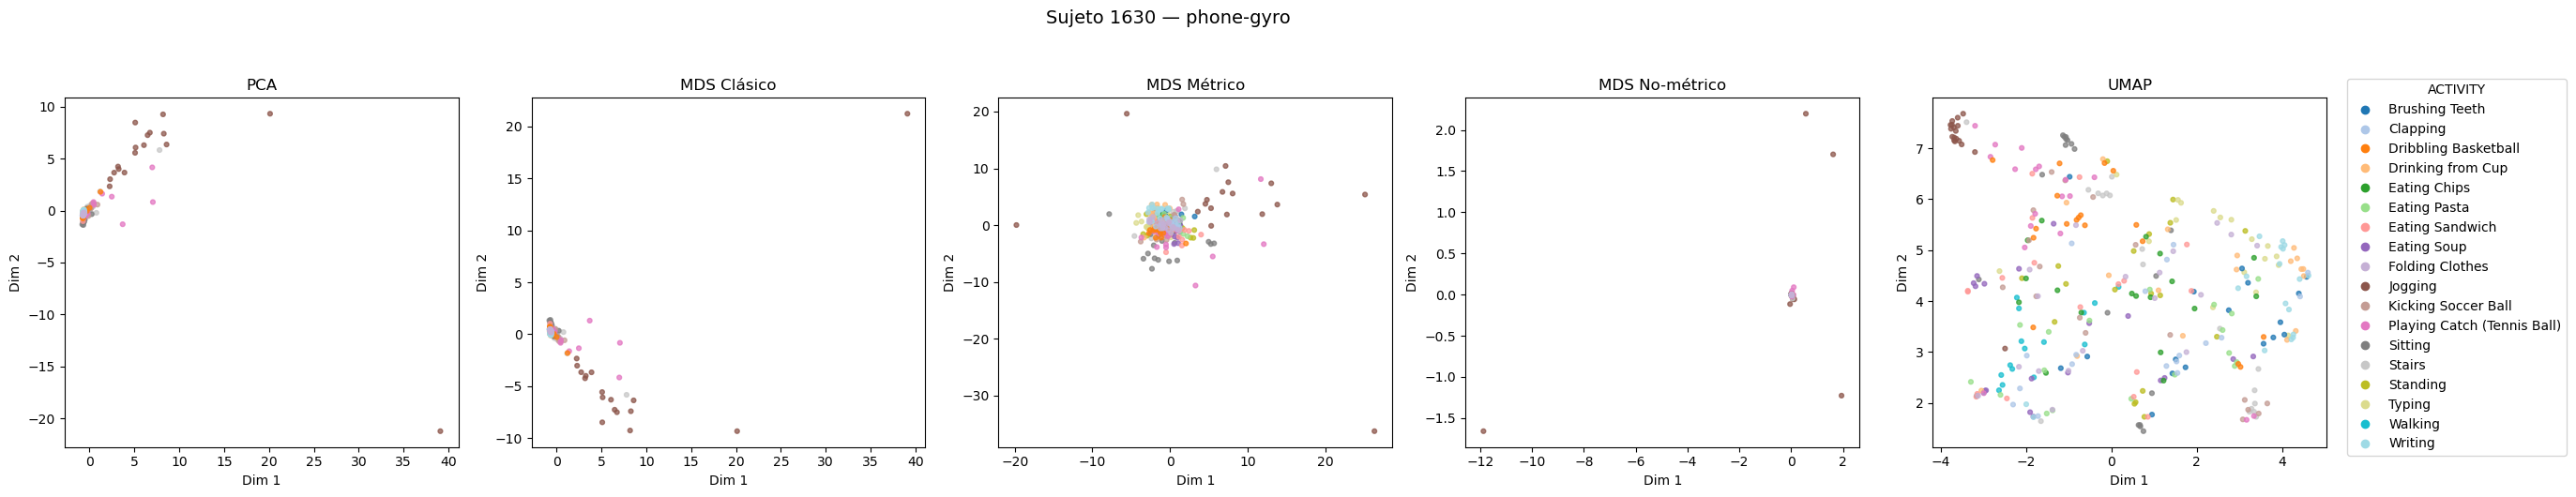

Sujeto 1630 - watch-accel: 324 filas, 30 columnas, 18 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


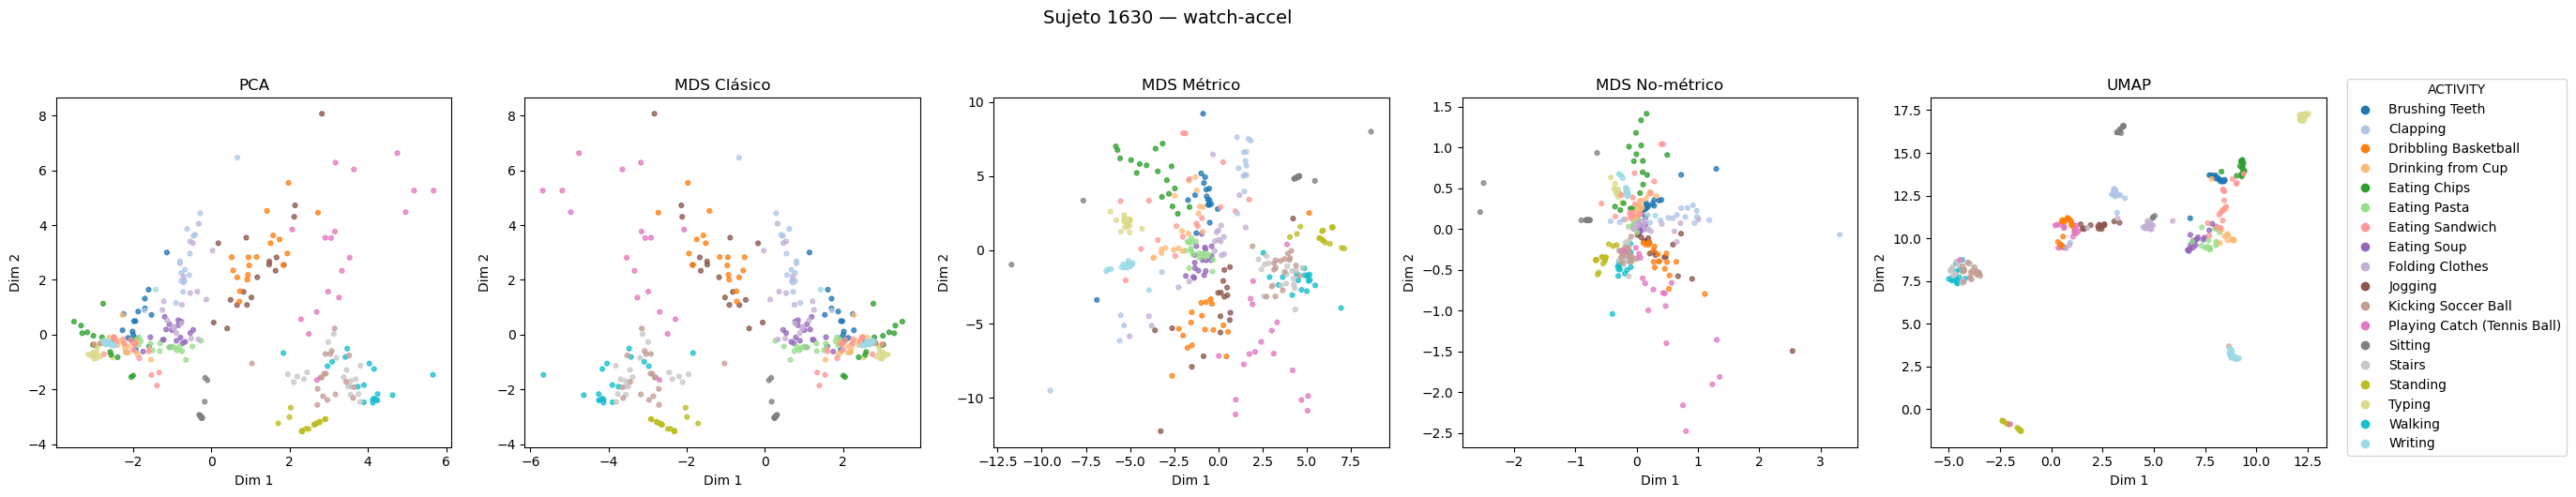

Sujeto 1630 - watch-gyro: 324 filas, 30 columnas, 18 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


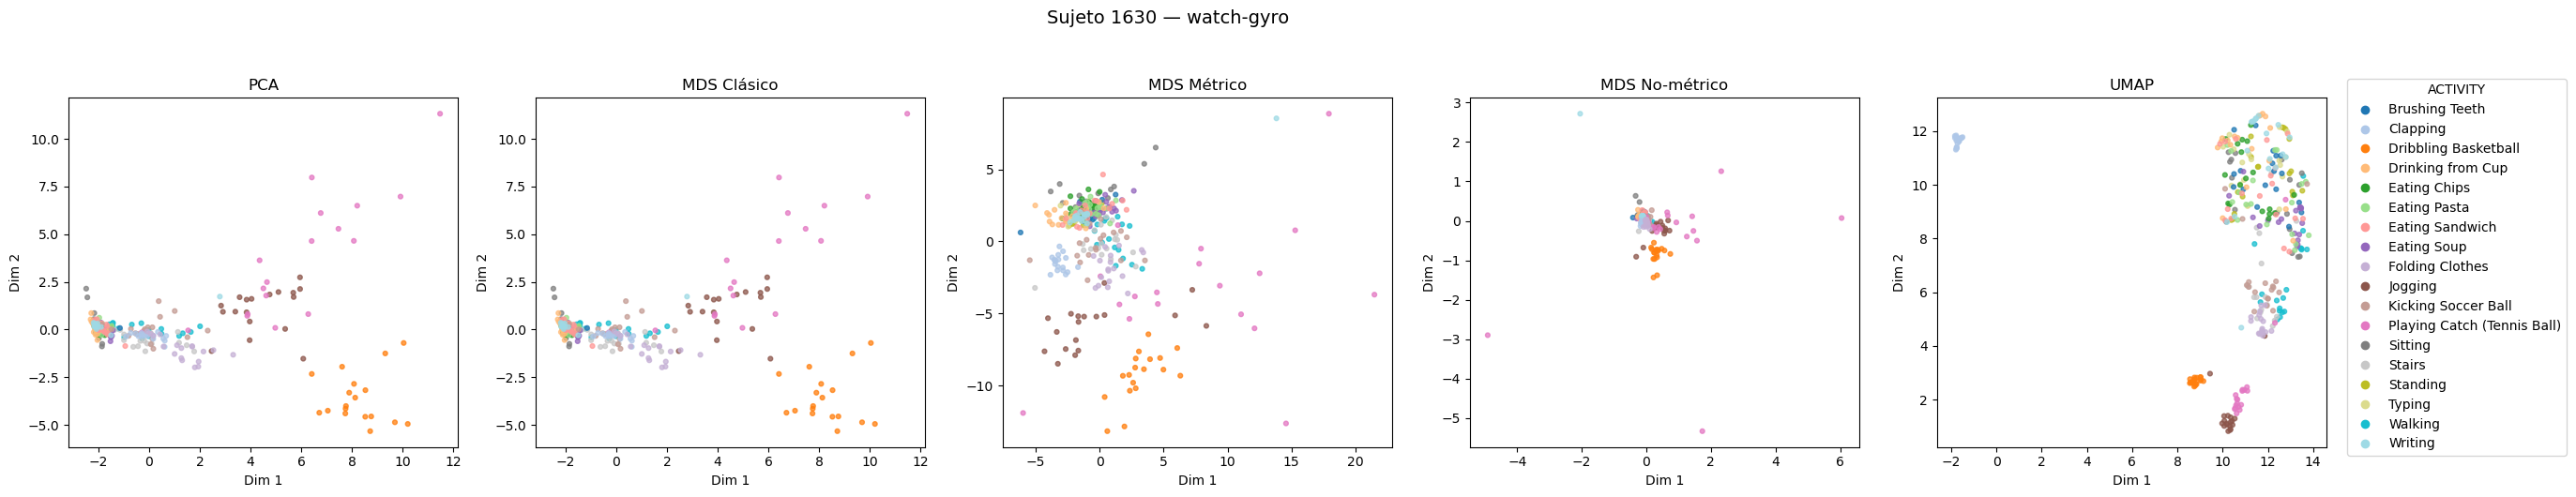

Sujeto 1634 - phone-accel: 321 filas, 30 columnas, 18 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


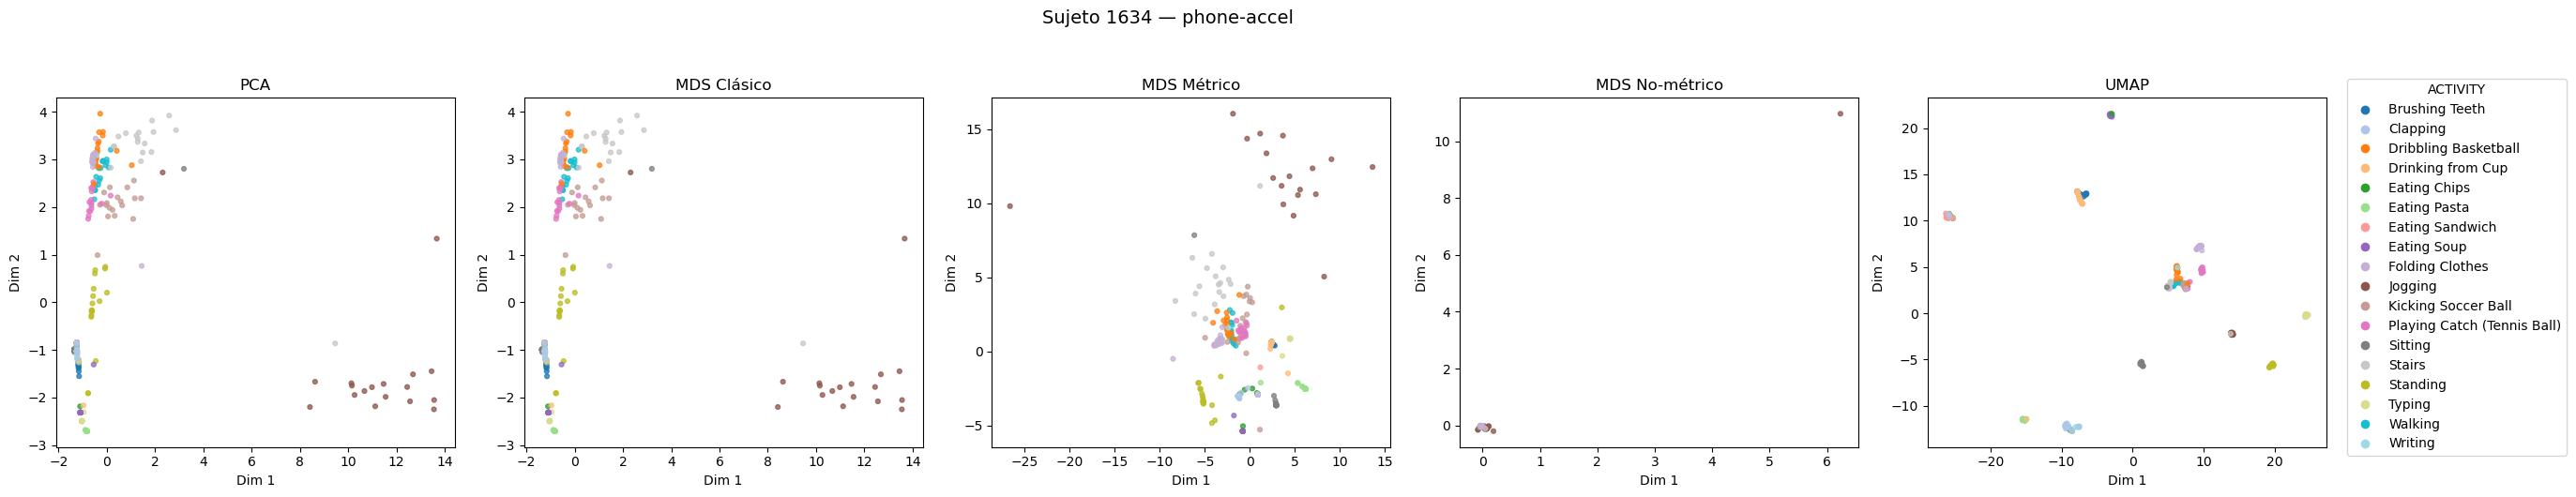

Sujeto 1634 - phone-gyro: 321 filas, 30 columnas, 18 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


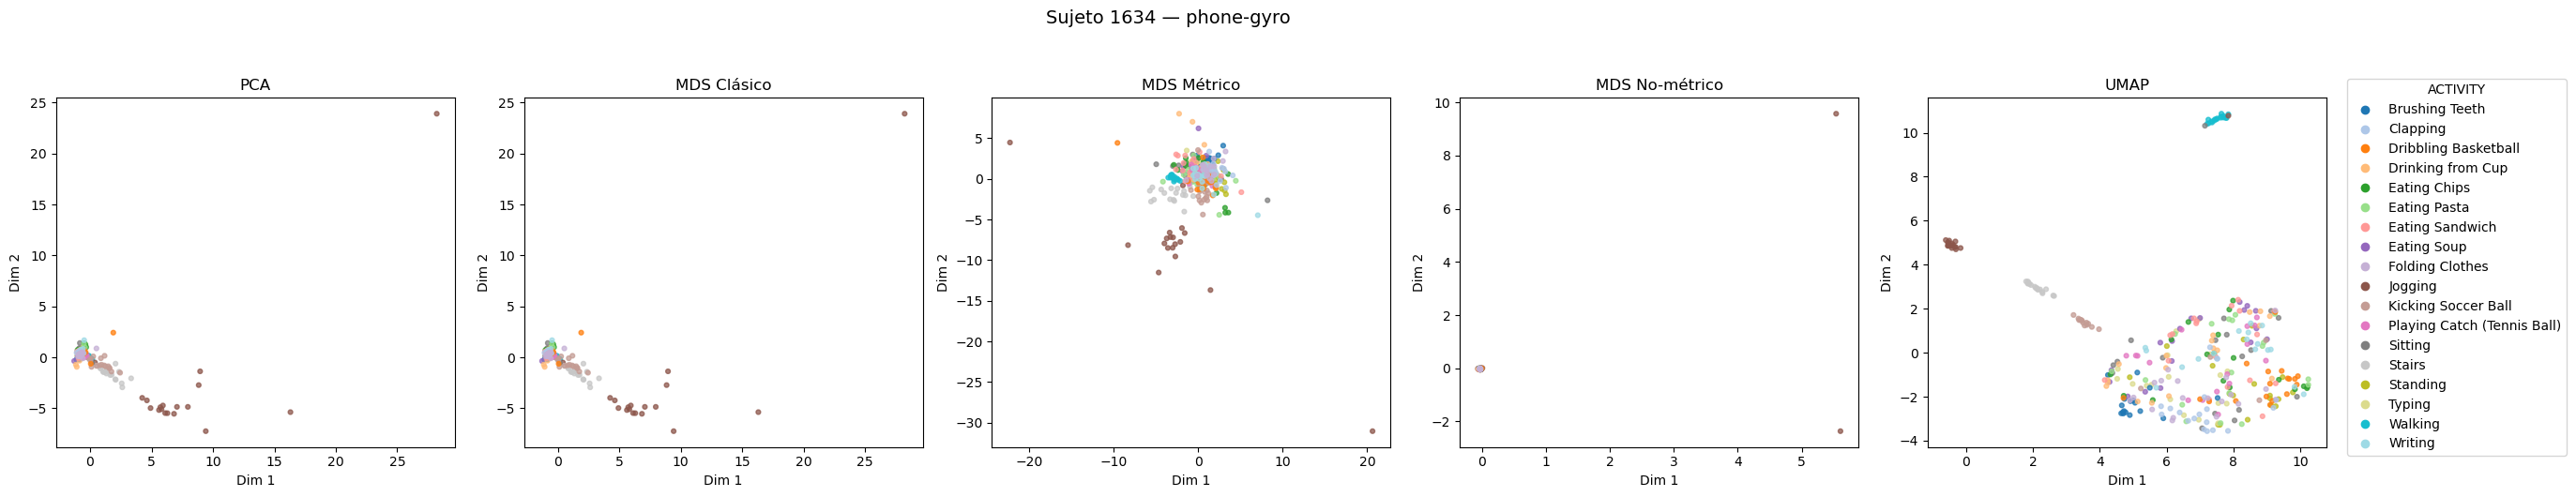

Sujeto 1634 - watch-accel: 324 filas, 30 columnas, 18 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


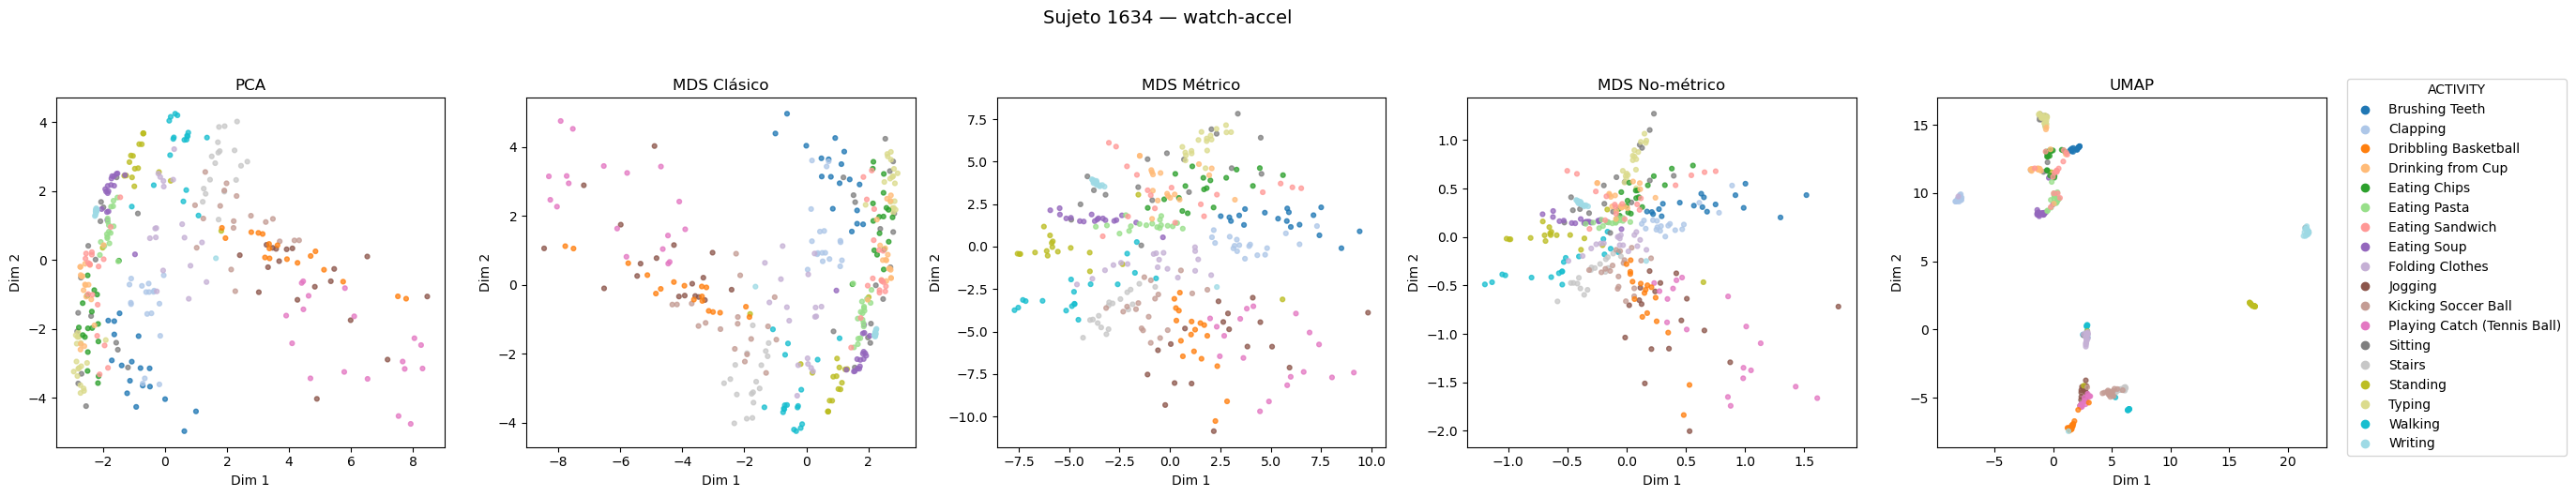

Sujeto 1634 - watch-gyro: 324 filas, 30 columnas, 18 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


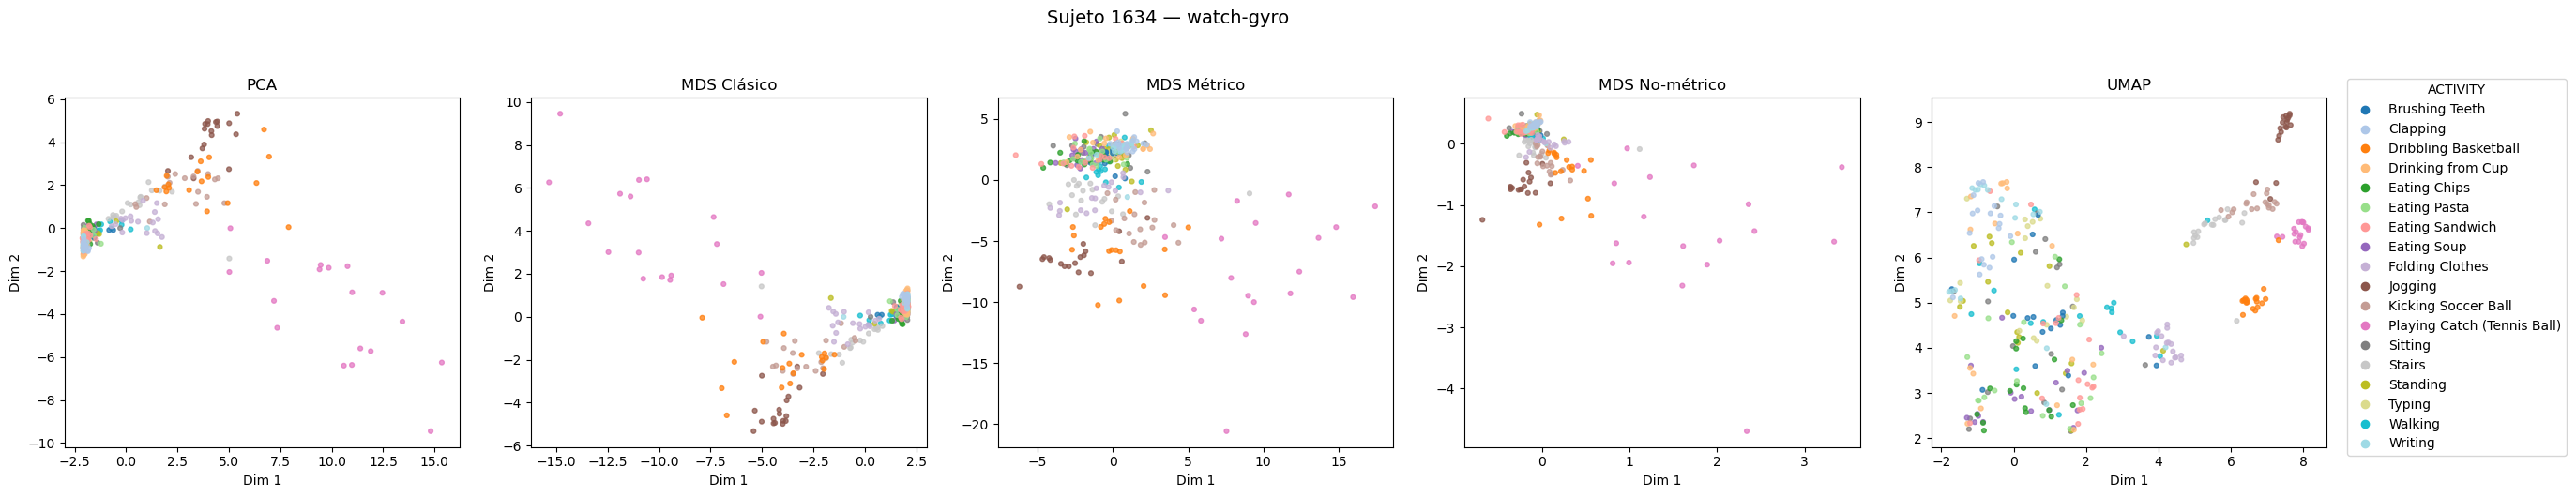

Sujeto 1638 - phone-accel: 324 filas, 30 columnas, 18 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


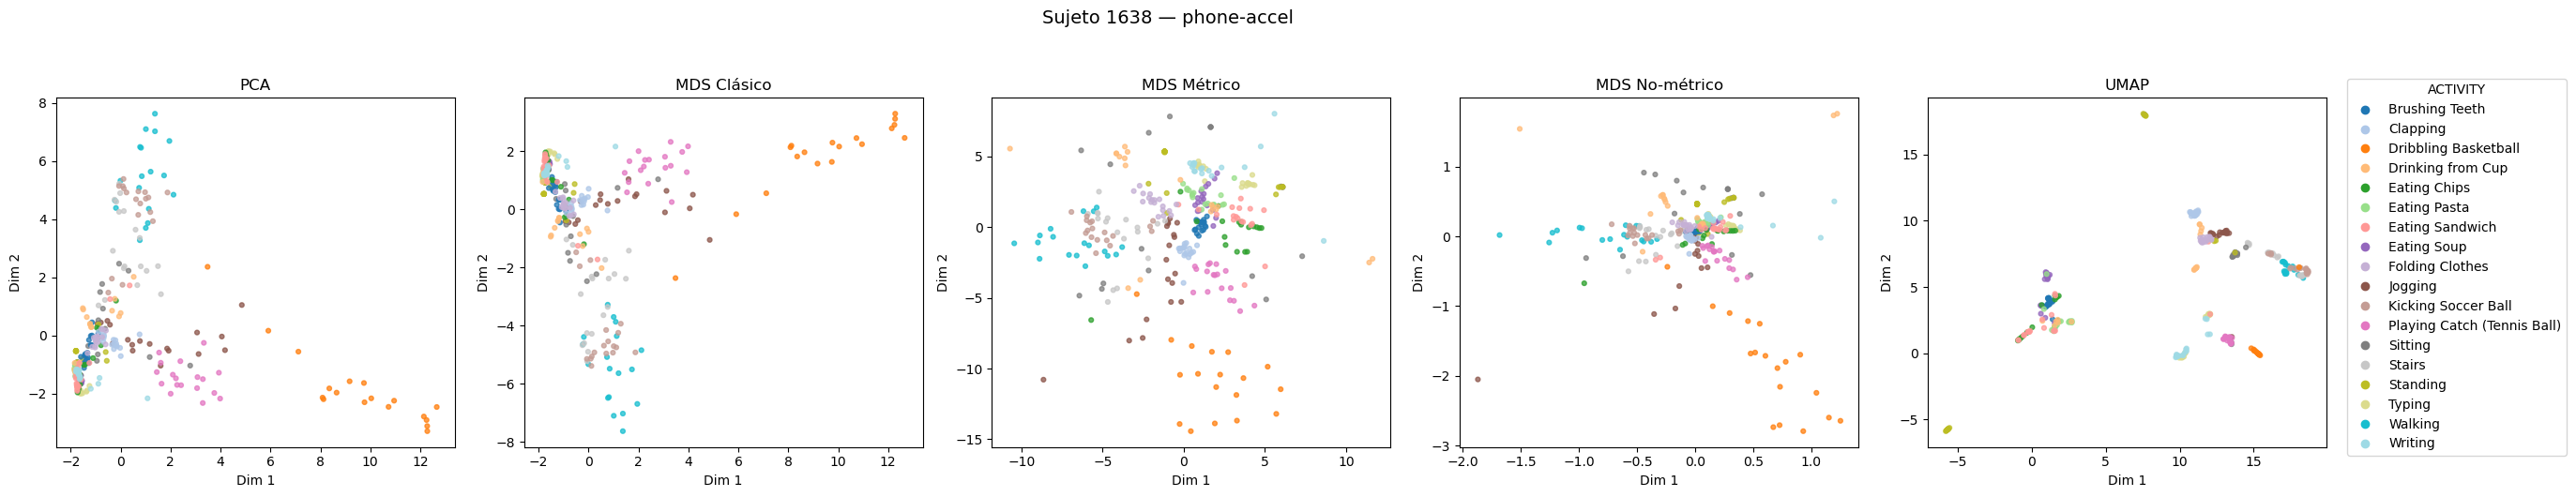

Sujeto 1638 - phone-gyro: 323 filas, 30 columnas, 18 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


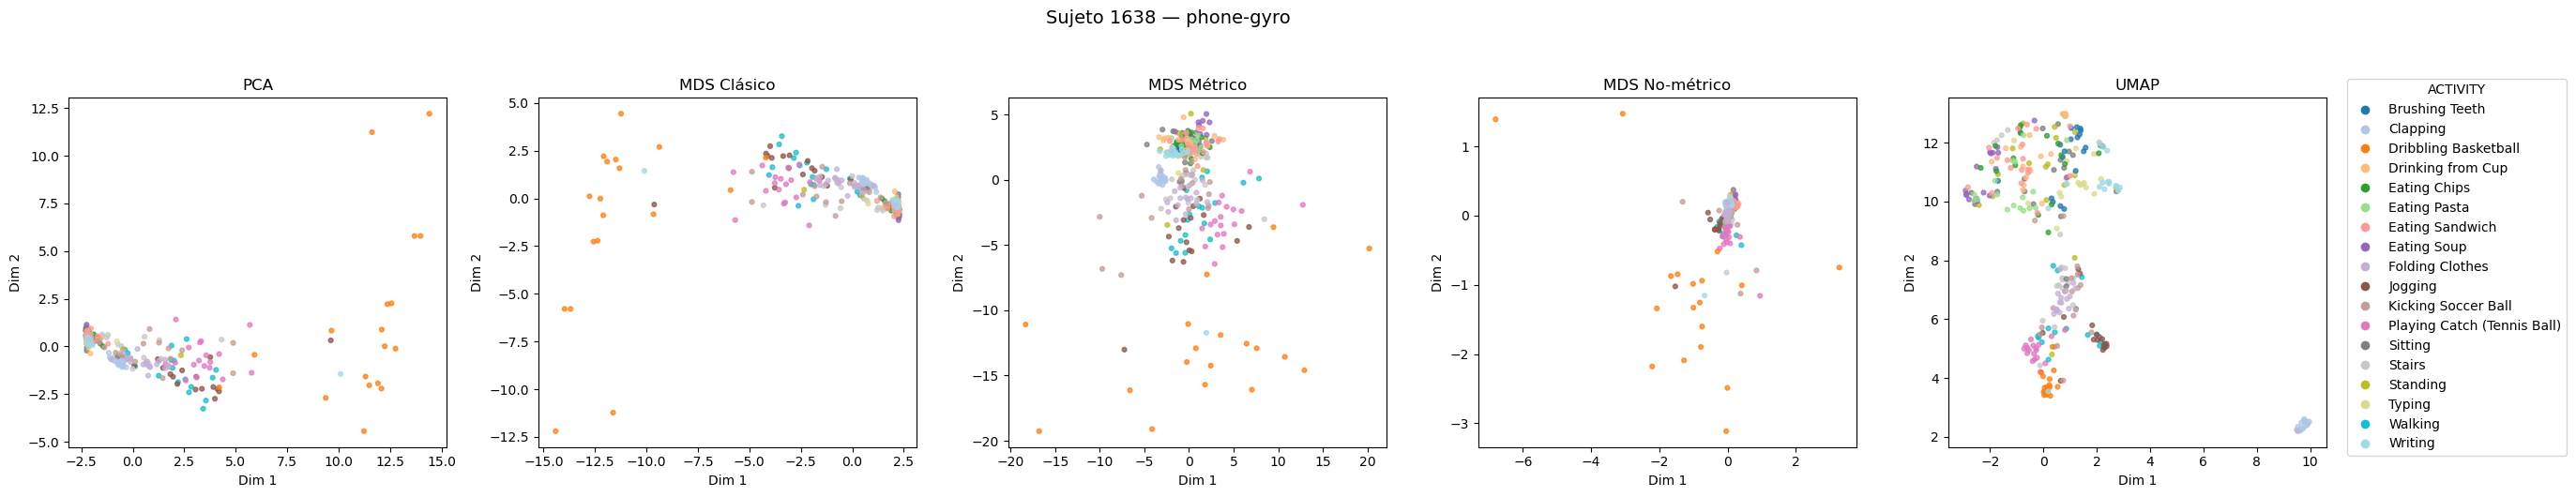

Sujeto 1638 - watch-accel: 803 filas, 30 columnas, 18 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


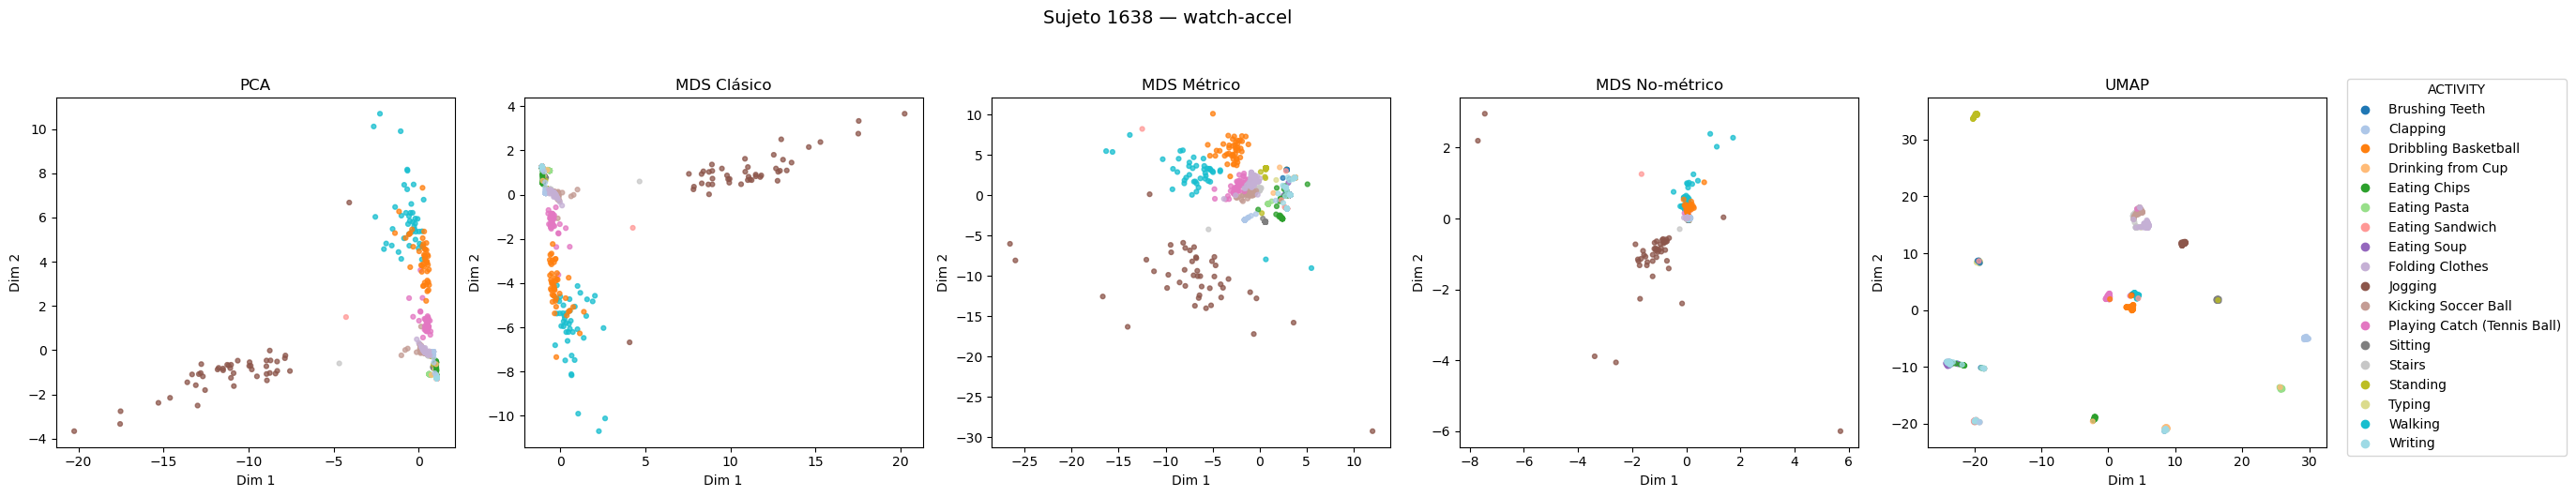

Sujeto 1638 - watch-gyro: 357 filas, 30 columnas, 16 actividades


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


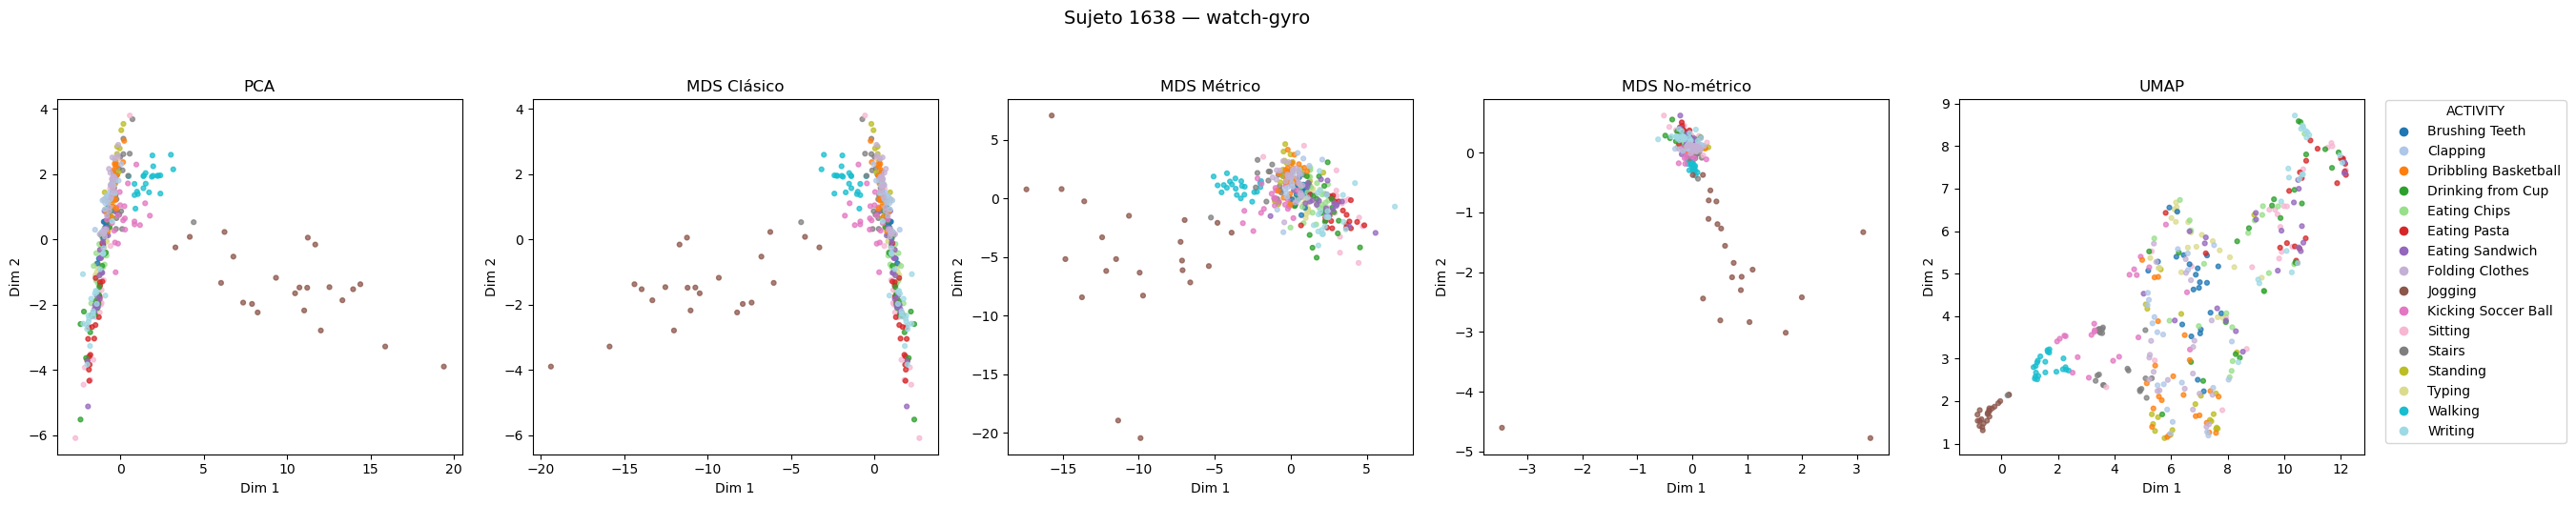

In [28]:
individual_data = {}  # (subject, case_name) -> (X, y_code, y_name)

for subject in SUBJECTS:
    for case_name, (device, sensor) in CASES.items():
        X, y_code, y_name = build_case_matrix(subject, device, sensor)
        individual_data[(subject, case_name)] = (X, y_code, y_name)
        print(f"Sujeto {subject} - {case_name}: {X.shape[0]} filas, {X.shape[1]} columnas, "
              f"{len(pd.unique(y_name))} actividades")
        results = reduce_all(X)
        plot_embeddings(results, y_name, f"Sujeto {subject} — {case_name}")


## 7. Parte 2 — Análisis combinando las tres muestras

Para cada una de las 4 combinaciones dispositivo-sensor, se unen (`concatenan`) las matrices de
los 3 sujetos en una sola, y se repite la visualización 2D con las 5 técnicas.


phone-accel (3 sujetos combinados): 966 filas, 30 columnas


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


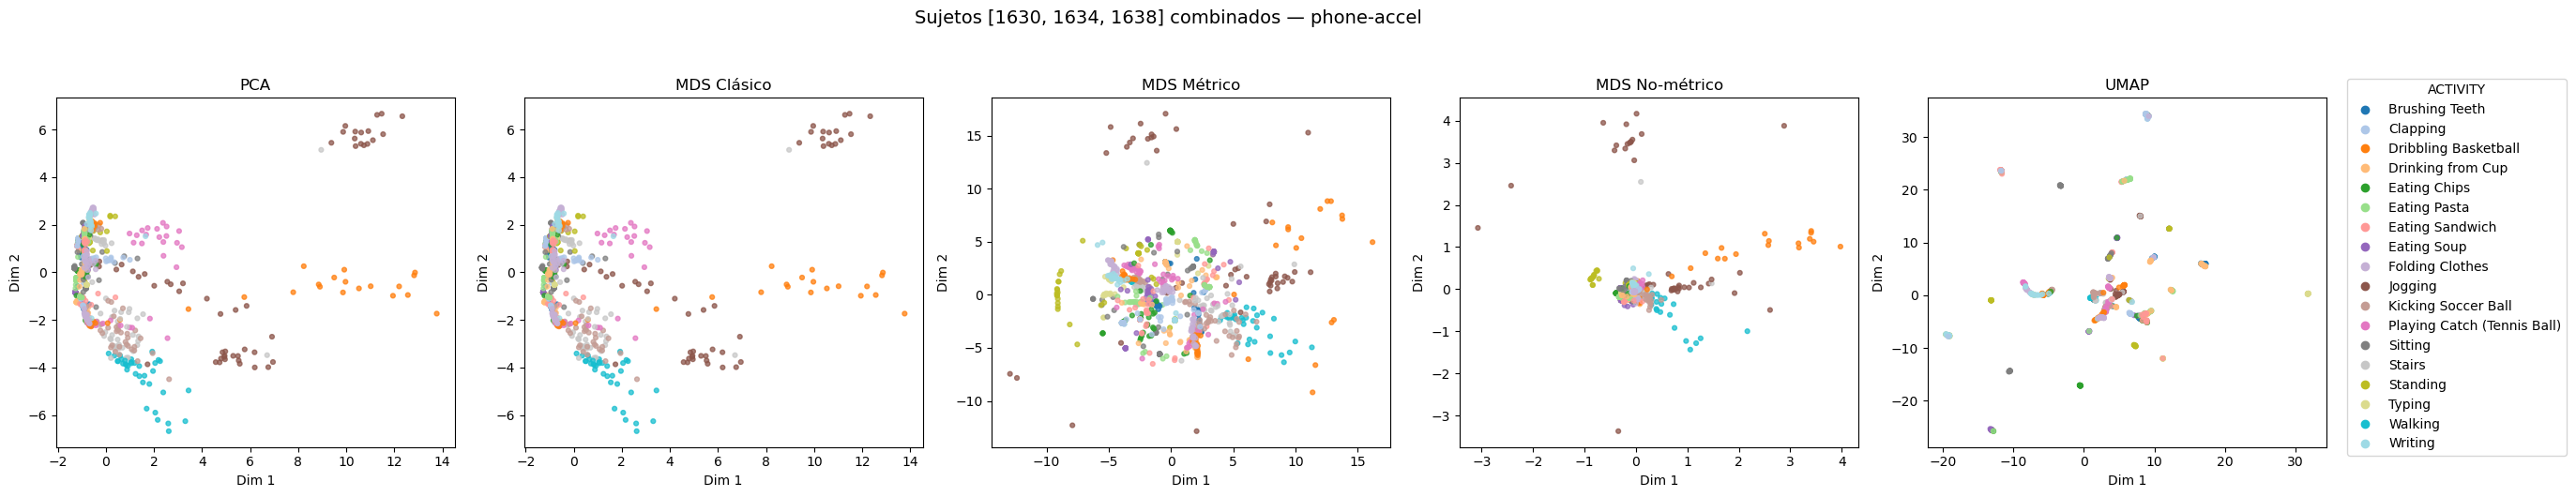

phone-gyro (3 sujetos combinados): 965 filas, 30 columnas


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


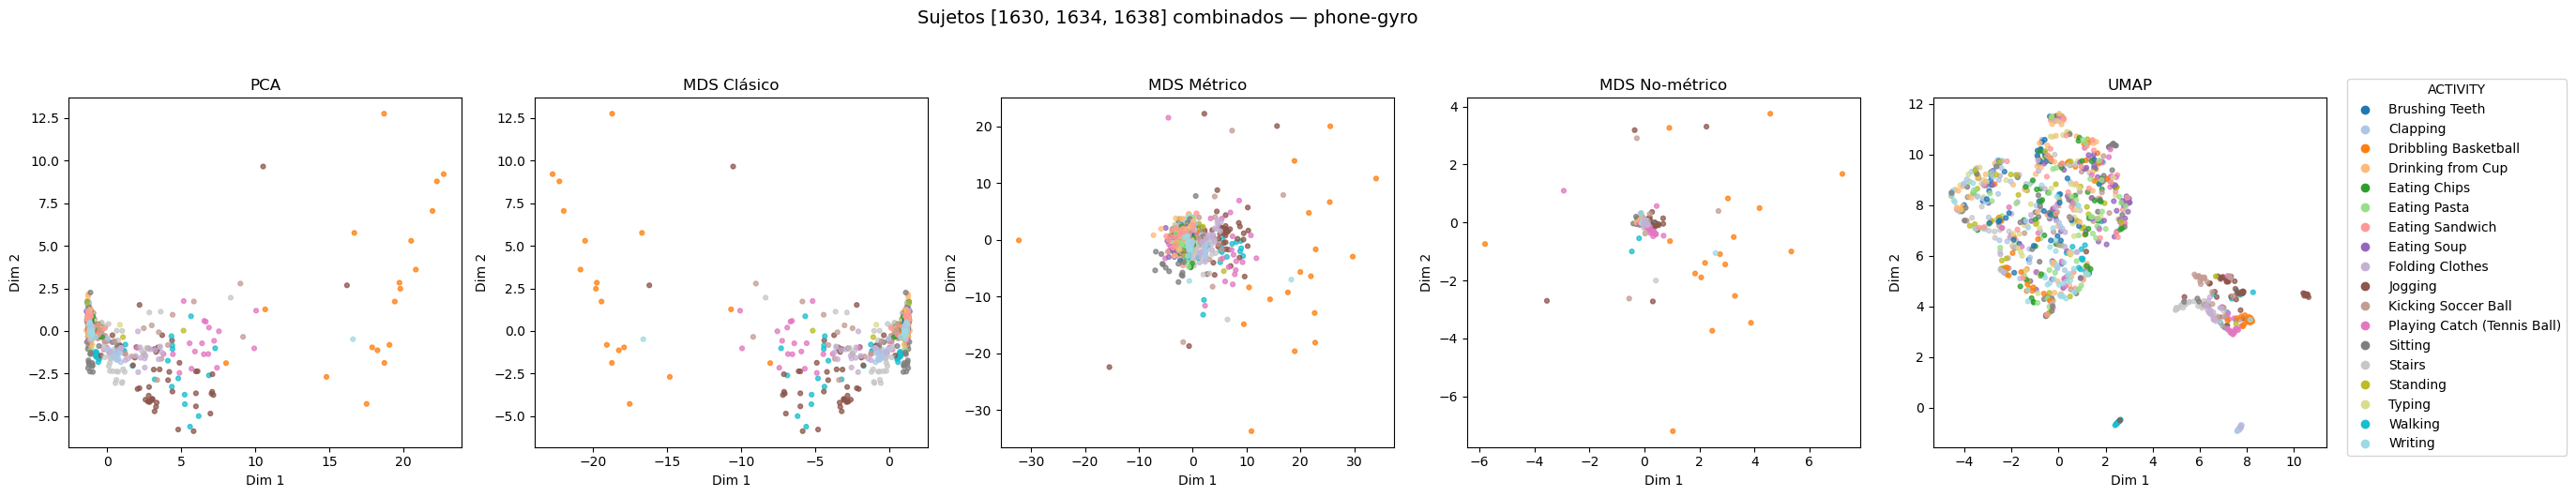

watch-accel (3 sujetos combinados): 1451 filas, 30 columnas


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


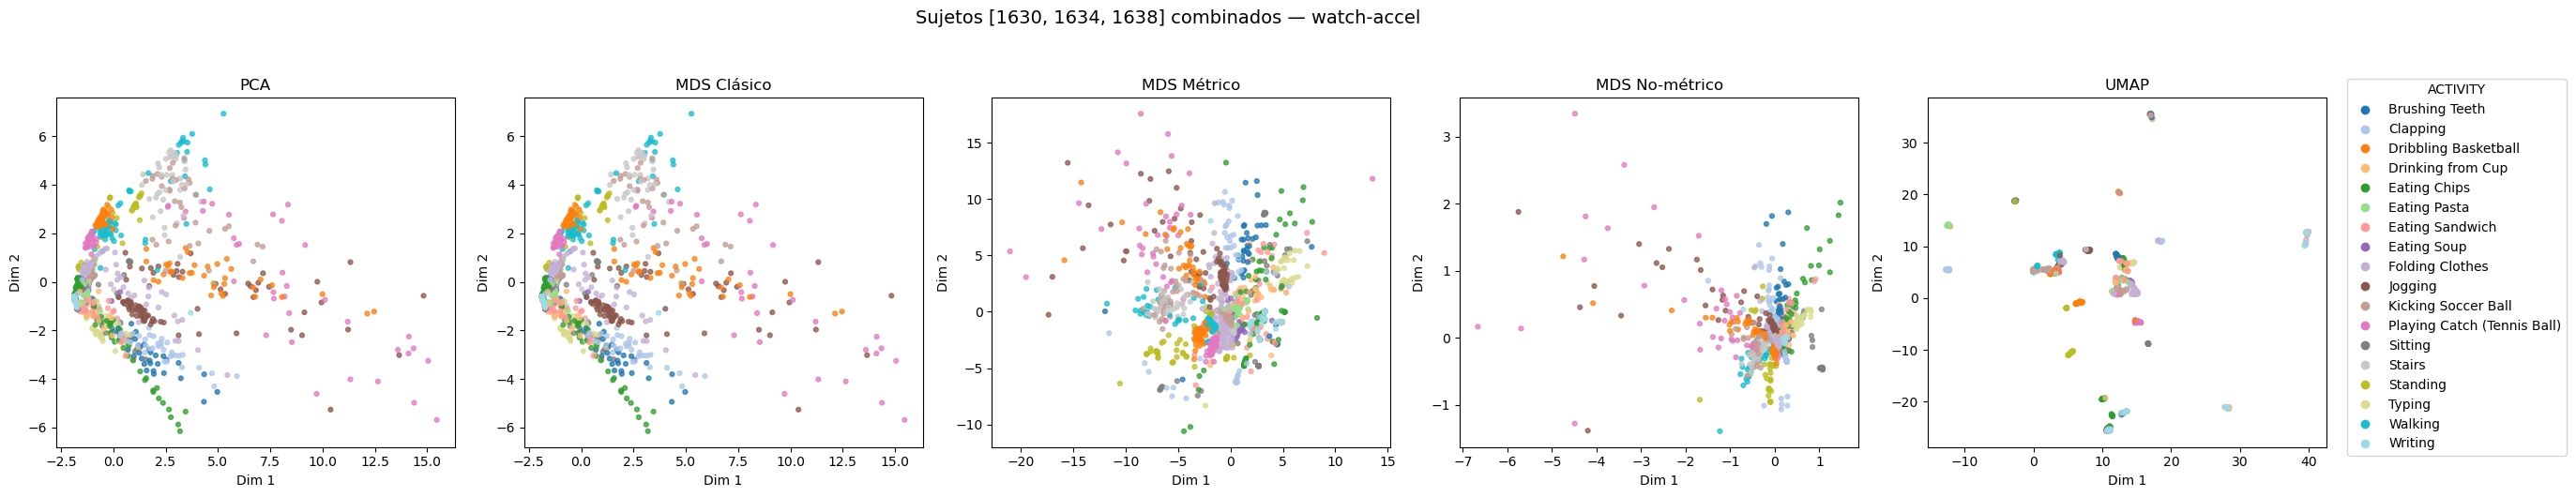

watch-gyro (3 sujetos combinados): 1005 filas, 30 columnas


c:\Users\HP\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


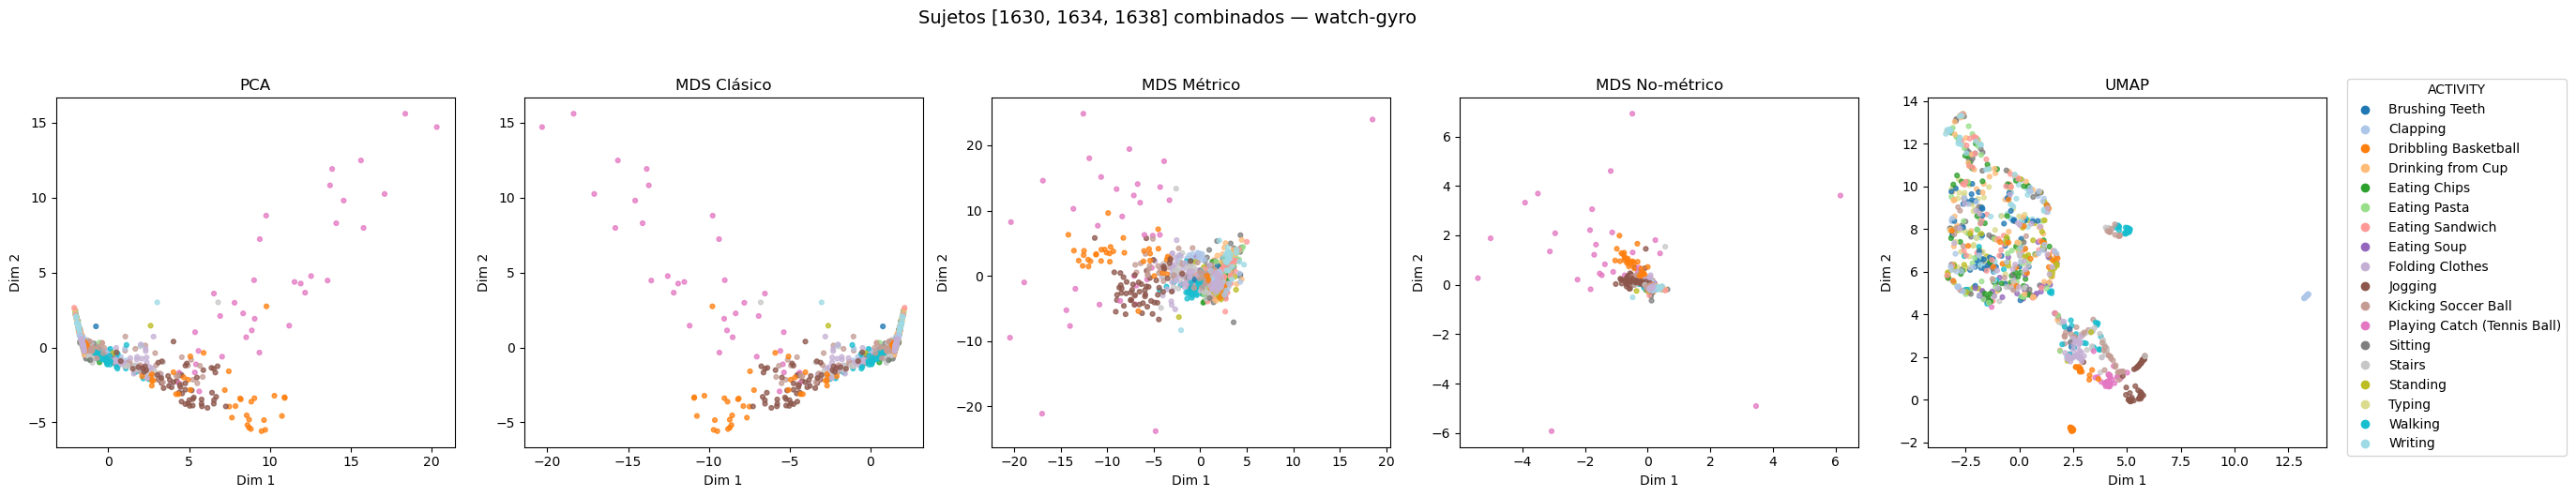

In [29]:
combined_data = {}  # case_name -> (X_all, y_code_all, y_name_all)

for case_name, (device, sensor) in CASES.items():
    Xs, y_codes, y_names = [], [], []
    for subject in SUBJECTS:
        X, y_code, y_name = individual_data[(subject, case_name)]
        Xs.append(X)
        y_codes.append(y_code)
        y_names.append(y_name)

    X_all = np.vstack(Xs)
    y_code_all = np.concatenate(y_codes)
    y_name_all = np.concatenate(y_names)
    combined_data[case_name] = (X_all, y_code_all, y_name_all)

    print(f"{case_name} (3 sujetos combinados): {X_all.shape[0]} filas, {X_all.shape[1]} columnas")
    # n_init reducido para las MDS iterativas debido al mayor tamaño de la matriz combinada
    results = reduce_all(X_all, n_init=2, max_iter=300)
    plot_embeddings(results, y_name_all, f"Sujetos {SUBJECTS} combinados — {case_name}")

## 8. Discusión de resultados

 **Alcance de este análisis:** esta discusión se basa únicamente en la **Parte 2 del punto 7**, es decir, en las gráficas donde se unió la información de los 3 sujetos seleccionados aleatoriamente (**1630, 1634, 1638**) en una sola matriz, para cada una de las 4 combinaciones dispositivo-sensor: `phone-accel`, `phone-gyro`, `watch-accel` y `watch-gyro`. No se incluyen aquí las gráficas individuales por sujeto (Parte 1).

### ¿Qué actividades se diferencian mejor en dos dimensiones?

Revisando las 4 combinaciones dispositivo-sensor:

- **Dribbling Basketball**: es la más consistente. En las **4 combinaciones** (`phone-accel`, `phone-gyro`, `watch-accel`, `watch-gyro`) forma un grupo de puntos claramente alejado de la nube principal, tanto en PCA/MDS Clásico como en MDS Métrico.
- **Playing Catch (Tennis Ball)**: en `watch-gyro` y `watch-accel` es la actividad que **más** se aleja de todas — forma un brazo largo de puntos muy separado del resto de la nube.
- **Jogging**: se separa bien en `phone-accel` (incluso aparece dividido en dos subgrupos, ambos lejos de la nube principal).
- **Walking**: se separa bien en `phone-accel` y `phone-gyro` (forma su propia banda de puntos), pero esta separación **desaparece** en `watch-accel` y `watch-gyro`, donde se mezcla con el resto.
- **Eating Chips**: en `watch-accel` forma un brazo de puntos bien definido y separado del resto. Esta separación **no se repite** en las otras 3 combinaciones.

**Resumen:** de las 18 actividades, solo 4-5 logran separarse de la nube principal en alguna combinación, y únicamente **Dribbling Basketball** lo hace en las 4 combinaciones a la vez.

### ¿Qué actividades se superponen en dos dimensiones?

- Existe un grupo grande de actividades que aparece **siempre mezclado** entre sí, en las 4 combinaciones y con las 5 técnicas:
  **Sitting, Standing, Typing, Writing, Clapping, Brushing Teeth, Folding Clothes, Drinking from Cup, Eating Pasta, Eating Sandwich, Eating Soup, Stairs y Kicking Soccer Ball.**
- **Stairs** en particular aparece disperso dentro de ese blob mezclado en las 4 combinaciones, sin agruparse claramente ni con el bloque anterior ni con ninguna otra actividad.
- En `watch-accel`, dentro de ese mismo blob mezclado, **Brushing Teeth** y **Clapping** se ven un poco más cercanos entre sí que del resto — aunque siguen dentro de la nube general y no forman un grupo totalmente aparte.

### Conclusión general 

Con los 3 sujetos combinados (1630, 1634, 1638), el patrón que se repite en las 4 combinaciones dispositivo-sensor es:

- Un pequeño número de actividades (4-5) se separan de la nube principal, y esto varía según el sensor/dispositivo usado.
- Las 13 actividades restantes quedan agrupadas en un único bloque difícil de discriminar en 2D, sin importar cuál de las 5 técnicas de reducción (PCA, MDS Clásico, MDS Métrico, MDS No-métrico, UMAP) se utilice.

